# Siemens TWIX -> deepinv multi-coil MRI

Raw Siemens `.dat` -> labelled k-space grid
-> ESPIRiT coil sensitivities -> `MultiCoilMRI` forward operator, then compare the
adjoint against a SENSE reconstruction on a single slice.

Authors: George Hammerton (St Geoerge's NHS), Margaret Duff (STFC-UKRI), Emily Redpath (St George's NHS), Ben Hawkes (University of Edinburgh), Matthieu Terris (Blur Labs )


## 0. Imports and helper functions 

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from twixtools import map_twix
import deepinv as dinv

device = dinv.utils.get_device()


def as_image(x):
    """deepinv tensor (1, 2, H, W) -> 2D magnitude array."""
    x = x.detach().cpu()
    if x.shape[1] == 2:  # real/imag channels
        x = torch.view_as_complex(x.moveaxis(1, -1).contiguous()).abs()
    return x.squeeze().numpy()


def show(img, ax, title="", cmap="gray", vmin=0, p=99.75, cbar=True):
    """imshow with percentile windowing, no ticks/spines, axis-matched colorbar."""
    img = np.asarray(img)
    vmax = np.percentile(img, p) if p is not None else img.max()
    m = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    if cbar:
        h, w = img.shape[-2:]
        ax.figure.colorbar(m, ax=ax, fraction=0.047 * h / w, pad=0.02)
    return m

Selected GPU 0 with 15144.5625 MiB free memory


### Datasets 

Example public datasets you could run this on: 
- Epi.dat and gre.dat from twixtools example data https://github.com/pehses/twixtools/tree/master/example_data
- meas_MID03485_FID51095_se.dat from https://zenodo.org/records/33166 

## 1. Load raw k-space

`map_twix` sorts the raw acquisition lines into a labelled 16-D grid. We keep
`Cha`/`Lin`/`Col` (and `Sli` unless a single slice is requested) and take index 0 of
anything else, warning if a dropped dimension was non-singleton.

In [ ]:
path = "meas_MID03485_FID51095_se.dat"

#path = "gre.dat"


def load_siemanns_dat(path, extract_slice=None, remove_os=True, create_mask=False):
    r"""Load a Siemens .dat file as a deepinv-style k-space tensor.

    Args:
        path (str): path to the Siemens .dat file.
        extract_slice (int, optional): extract only this slice index. Defaults to None (all slices).
        remove_os (bool): remove 2x readout oversampling. Defaults to True.
        create_mask (bool): also return a sampling mask from the non-zero k-space lines.

    Returns:
        torch_kspace (torch.Tensor): k-space, shape (1, 2, Cha, [Sli,] Lin, Col).
        info (dict): ``n_coils`` and the image ``shape``.
        mask (torch.Tensor): sampling mask, only if ``create_mask``.
    """
    mapped = map_twix(path)
    im = mapped[-1]["image"]  # last scan; earlier ones are noise/adjustment scans
    im.flags["remove_os"] = remove_os
    im.flags["zf_missing_lines"] = True

    dim_order = im.dim_order  
    arr_size = {d: int(im.size[d]) for d in dim_order}
    print(f"  found array of size {arr_size}")

    index, kept, extra = [], [], {}
    for d in dim_order:
        if d in ("Lin", "Cha", "Col") or (d == "Sli" and extract_slice is None):
            index.append(slice(None))
            kept.append(d)
        elif d == "Sli":
            index.append(extract_slice)
        else:
            if arr_size[d] > 1:
                extra[d] = arr_size[d]
            index.append(0)
    if extra:
        print(f"  note: taking index 0 of extra non-singleton dims {extra}")

    kspace = im[tuple(index)]
    # to (Cha, [Sli,] Lin, Col); permutation derived from dim_order so it holds
    # whatever order the file stores its dimensions in
    target = [d for d in ("Cha", "Sli", "Lin", "Col") if d in kept]
    kspace = np.transpose(kspace, [kept.index(d) for d in target])
    print(f"  kept {target} -> {kspace.shape}")

    torch_kspace = torch.from_numpy(kspace)
    if create_mask:
        mask = torch.squeeze(torch.abs(torch_kspace).sum(dim=0) > 0)

    shape = kspace.shape
    torch_kspace = dinv.utils.MRIMixin().from_torch_complex(torch_kspace.unsqueeze(0))
    info = {"n_coils": arr_size["Cha"], "shape": shape[1:]}

    return (torch_kspace, info, mask) if create_mask else (torch_kspace, info)


ks, info, mask = load_siemanns_dat(path, extract_slice=0, remove_os=True, create_mask=True)
print(ks.shape, info)

Software version: VD/VE (!?)

Scan  0


  0%|          | 0.00/32.3M [00:00<?, ?B/s]

100%|██████████| 32.3M/32.3M [00:00<00:00, 1.86GB/s]


Scan  1


100%|██████████| 129M/129M [00:00<00:00, 3.24GB/s]

  found array of size {'Ide': 1, 'Idd': 1, 'Idc': 1, 'Idb': 1, 'Ida': 1, 'Seg': 1, 'Set': 1, 'Rep': 1, 'Phs': 1, 'Eco': 1, 'Par': 1, 'Sli': 1, 'Ave': 1, 'Lin': 512, 'Cha': 32, 'Col': 512}


  kept ['Cha', 'Lin', 'Col'] -> (32, 512, 512)
torch.Size([1, 2, 32, 512, 512]) {'n_coils': 32, 'shape': (512, 512)}


## 2. Sampling pattern and raw k-space

Sanity check before anything else: energy should be concentrated at the centre of
k-space, and the mask should show which phase-encode lines were actually acquired.

Text(0.5, 0.98, 'Slice 10, 32 coils, 512x512')

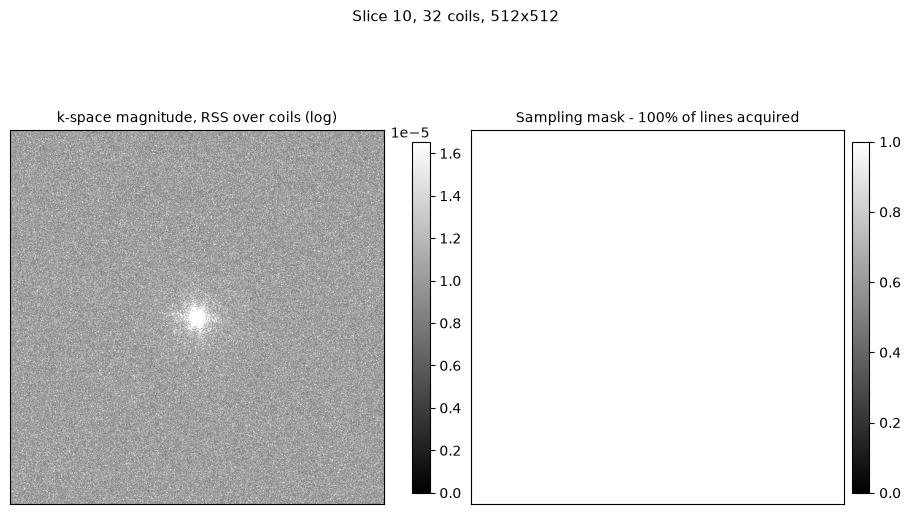

In [3]:
kc = dinv.utils.MRIMixin().to_torch_complex(ks).squeeze(0)  # (Cha, Lin, Col) complex
rss_k = kc.abs().pow(2).sum(0).sqrt().numpy()               # coil-combined k-space

frac = mask.float().mean().item()
fig, axes = plt.subplots(1, 2, figsize=(9, 6), constrained_layout=True)
show(np.log1p(rss_k), axes[0], "k-space magnitude, RSS over coils (log)", p=99.5)
show(mask.numpy().astype(float), axes[1], f"Sampling mask - {frac:.0%} of lines acquired", p=None)
fig.suptitle(f"Slice 10, {info['n_coils']} coils, {info['shape'][0]}x{info['shape'][1]}", fontsize=11)

## 3. Coil sensitivity maps

Note only works on single slices

torch.Size([1, 32, 512, 512]) torch.complex64


Text(0.5, 0.98, 'ESPIRiT coil sensitivity magnitudes')

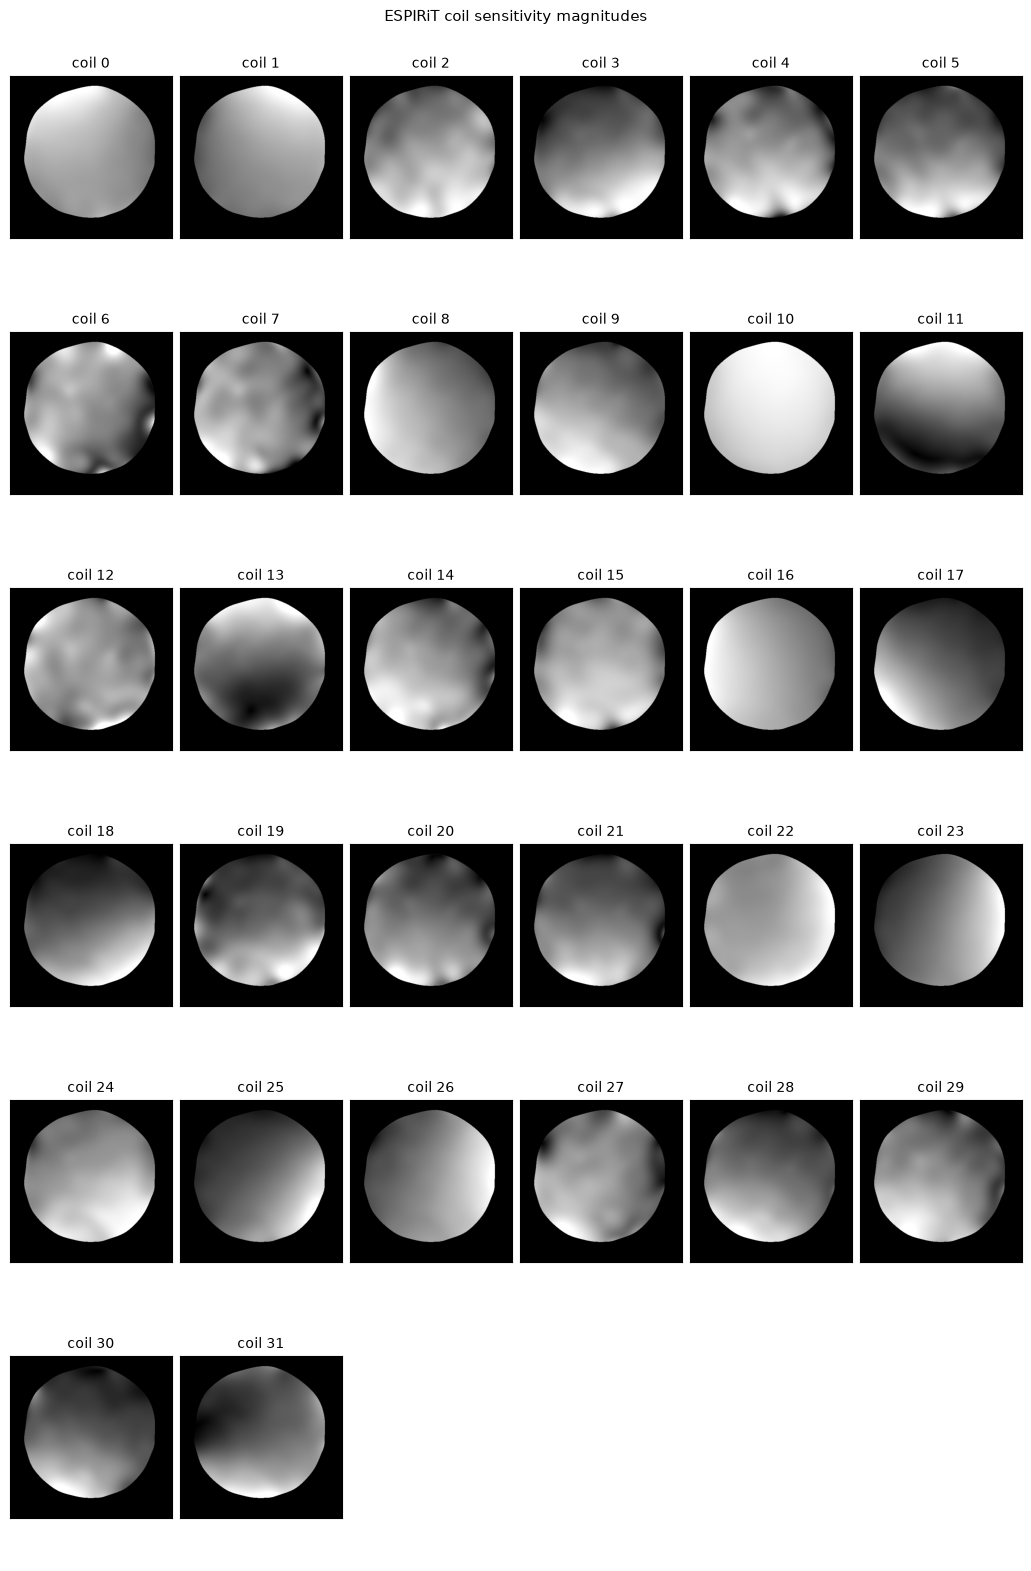

In [4]:
coil_maps = dinv.physics.MultiCoilMRI.estimate_coil_maps(ks, calib_size=24, use_cupy=False)
print(coil_maps.shape, coil_maps.dtype)

cm = coil_maps.squeeze(0).cpu()  # (Cha, Lin, Col) complex
ncol = 6
nrow = int(np.ceil(cm.shape[0] / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(1.7 * ncol, 2.6 * nrow), constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    if i < cm.shape[0]:
        show(cm[i].abs().numpy(), ax, f"coil {i}", cbar=False)
    else:
        ax.axis("off")
fig.suptitle("ESPIRiT coil sensitivity magnitudes", fontsize=11)

## 4. Forward operator


In [5]:
forward = dinv.physics.MultiCoilMRI(
    mask=mask,
    coil_maps=coil_maps,
    img_size=info["shape"],
    device=device,
    three_d=False,
)


## 5. Reconstruction

Adjoint $A^{H}y$ (coil-combined, no de-aliasing) against the SENSE least-squares
solution $A^{\dagger}y$.

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_771024/2526688536.py:7: SyntaxWarning: invalid escape sequence '\d'
  show(as_image(sense), axes[1], "SENSE  $A^{\dagger}y$")


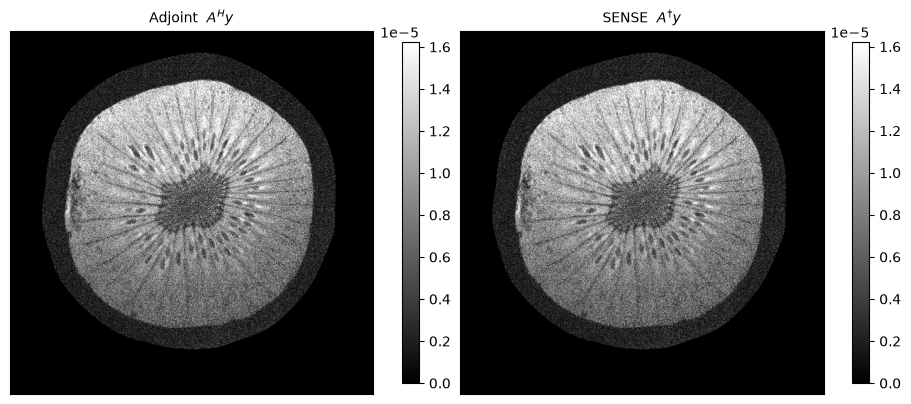

In [6]:
y = ks.to(device)
adjoint = forward.A_adjoint(y)
sense = forward.A_dagger(y)

fig, axes = plt.subplots(1, 2, figsize=(9, 6), constrained_layout=True)
show(as_image(adjoint), axes[0], "Adjoint  $A^{H}y$")
show(as_image(sense), axes[1], "SENSE  $A^{\dagger}y$")